In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

In [46]:
print('=' * 60)
print("INICIANDO A TAREFA 1.5 - ANALISE DO CLIENTE")
print('=' *60)

print("\n Carregando os arquivos necessarios")

INICIANDO A TAREFA 1.5 - ANALISE DO CLIENTE

 Carregando os arquivos necessarios


In [47]:
df_orders = pd.read_csv(r'C:\GameStoreBrasil\output\orders_cleaned.csv')
print(f' - orders_cleaned.csv :{df_orders.shape[0]} linhas e {df_orders.shape[1]} colunas')

df_games = pd.read_csv(r'C:\GameStoreBrasil\data\games.csv')
print(f' - games.csv :{df_games.shape[0]} linhas e {df_games.shape[1]} colunas')

df_members = pd.read_csv(r'C:\GameStoreBrasil\output\members_cleaned.csv')
print(f' - members_cleaned.csv :{df_games.shape[0]} linhas e {df_games.shape[1]} colunas')

 - orders_cleaned.csv :5000 linhas e 7 colunas
 - games.csv :80 linhas e 8 colunas
 - members_cleaned.csv :80 linhas e 8 colunas


In [48]:
#Verificação das primeiras 3 linhas

print(df_orders.head(3))
print(df_members.head(3))

   order_id  member_id game_id  quantity  unit_price           order_date  \
0         1        106   G0067         2      207.06  2025-02-01 09:11:00   
1         2        233   G0006         1       65.40  2024-11-27 15:02:00   
2         3        267   G0036         3       99.02  2024-09-26 14:37:00   

  promotion_id  
0            0  
1            0  
2            0  
   member_id      member_name   age gender   phone_number  \
0          1      Bruno Silva  47.0      M  5592975323506   
1          2     Rafael Gomes  50.0      F  5586943976280   
2          3  Guilherme Souza  52.0      F              0   

             join_date loyalty_tier churn_status  
0  2023-11-11 12:03:00       Silver      Churned  
1  2024-03-19 10:39:00         Gold       Active  
2  2022-10-09 13:08:00         Gold       Active  


In [49]:
#Vendo todos os tipos de dados 

print('\n Tipos de dados')
print('\n members_cleaned.csv')
print(df_members.dtypes)
print("\n orders_cleaned.csv")
print(df_orders.dtypes)


 Tipos de dados

 members_cleaned.csv
member_id         int64
member_name         str
age             float64
gender              str
phone_number      int64
join_date           str
loyalty_tier        str
churn_status        str
dtype: object

 orders_cleaned.csv
order_id          int64
member_id         int64
game_id             str
quantity          int64
unit_price      float64
order_date          str
promotion_id        str
dtype: object


In [50]:
#Estatisticas basicas da coluna age

print("\n --- Estatisticas basicas da coluna age ---")
print(f'minimo: {df_members['age'].min()}')
print(f'maximo: {df_members['age'].max()}')
print(f'media: {df_members['age'].mean()}')
print(f'mediana: {df_members['age'].median()}')


 --- Estatisticas basicas da coluna age ---
minimo: 16.0
maximo: 60.0
media: 38.876666666666665
mediana: 39.5


In [51]:
#Passo 2, Filtrar anomalisas e calcular receitas 
print("Passo 2, Filtrando anomalias")

linhas_antes = len(df_orders)

print(f' - Linhas em orders cleaned.csv antes do filtro {linhas_antes}')

Passo 2, Filtrando anomalias
 - Linhas em orders cleaned.csv antes do filtro 5000


In [52]:
#Filtrar valores negativos (Regras de ouro)

df_orders = df_orders[(df_orders['unit_price'] > 0) & (df_orders['quantity']>0)]

In [53]:
#3 Quantificar impacto do filtro
linhas_depois = len(df_orders) 
linhas_removidas = linhas_antes - linhas_depois
print(f'linhas apos o filtro: {linhas_depois}')
print(f'Linhas Removidas(Anomalias de qtd/preco <=0): {linhas_removidas}')

linhas apos o filtro: 4825
Linhas Removidas(Anomalias de qtd/preco <=0): 175


In [54]:
df_orders['revenue'] = df_orders['quantity'] * df_orders['unit_price']

In [55]:
print('\n --- Verificação: Primeiras 5 linhas com a nova coluna revenue ---')

colunas_verificacao = ['order_id', 'member_id', 'quantity', 'unit_price', 'revenue']
print(df_orders[colunas_verificacao].head())


 --- Verificação: Primeiras 5 linhas com a nova coluna revenue ---
   order_id  member_id  quantity  unit_price  revenue
0         1        106         2      207.06   414.12
1         2        233         1       65.40    65.40
2         3        267         3       99.02   297.06
3         4        292         2       52.23   104.46
4         5         40         2      207.06   414.12


In [56]:
df_merged = df_members.merge(df_orders, on = 'member_id', how = 'inner')


In [57]:
#Gasto medio por tier

idade_unicas = set(df_members['age'].unique())
series_counts = df_members['age'].value_counts()

print(f'{idade_unicas} Idades unicas')


{np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(31.0), np.float64(32.0), np.float64(33.0), np.float64(34.0), np.float64(35.0), np.float64(36.0), np.float64(37.0), np.float64(38.0), np.float64(39.5), np.float64(39.0), np.float64(41.0), np.float64(42.0), np.float64(43.0), np.float64(44.0), np.float64(45.0), np.float64(46.0), np.float64(47.0), np.float64(48.0), np.float64(49.0), np.float64(50.0), np.float64(51.0), np.float64(52.0), np.float64(53.0), np.float64(54.0), np.float64(55.0), np.float64(56.0), np.float64(57.0), np.float64(58.0), np.float64(59.0), np.float64(60.0), np.float64(40.0)} Idades unicas


In [58]:
#Agrupar idades por faixa etaria
bins = [17,24,34,44,200]

labels = [
    "18-24",
    "25-34",
    "35-44",
    "45+"
]

df_merged["faixa_etaria"] = pd.cut(
    df_members["age"],
    bins=bins,
    labels=labels,
    right= True,
    include_lowest = True
)



In [59]:
#3 Cortar a quantidade de clientes em cada faixa e ordenar pelo indice (ordem cronologica), e sort_index garante que as faixas apareçam organizadas 
age_dist = df_merged['faixa_etaria'].value_counts().sort_index()

print('\n --- Distribuição de Clientes por faixa etaria ---')
for faixa,qtd in age_dist.items():
    print(f' -faixa {faixa} : {qtd} clientes')


 --- Distribuição de Clientes por faixa etaria ---
 -faixa 18-24 : 48 clientes
 -faixa 25-34 : 49 clientes
 -faixa 35-44 : 79 clientes
 -faixa 45+ : 112 clientes


<Axes: xlabel='faixa_etaria'>

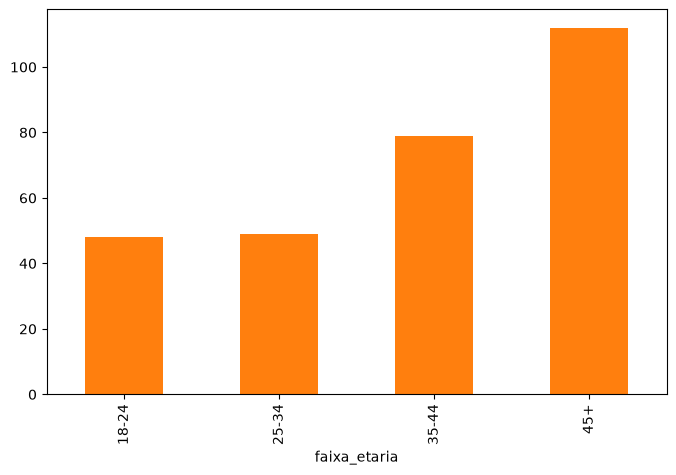

In [60]:
#Criar o Grafico de Barras

fig,ax = plt.subplots(figsize = (8,5))

#Plotar o grafico (kind = bar é essencial para dados categoricos)

age_dist.plot(kind = 'bar', ax = ax, color = '#ff7f0e', legend = False)

In [61]:
#Formatar o grafico

ax.set_title("Distribuição dos clientes por faixa etaria", fontsize = 14, fontweight = 'bold', pad = 15)
ax.set_ylabel("Numero de clientes", fontsize = 12)
ax.set_xlabel("Faixa Etaria", fontsize = 12)

Text(0.5, 24.336588541666657, 'Faixa Etaria')

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

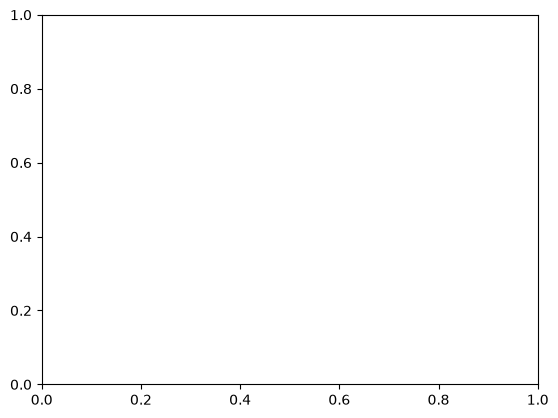

In [62]:
#Manter Rotulos do eixo X retos (0 Graus) para facilitar a leitura 
plt.xticks(rotation = 0)

In [63]:
#Adicionar os valores exatos em cima de cada barra
for i,v in enumerate(age_dist):
    ax.text(i, v + 2, str(v), ha = 'center', fontsize = 11, fontweight = 'bold')
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [64]:
caminho_grafico_idade = r'C:\GameStoreBrasil\output\temp_idade.png'
plt.savefig(caminho_grafico_idade, dpi = 150, bbox_inches = 'tight')

<Figure size 640x480 with 0 Axes>

In [65]:

df_merged['GastoMedio'] = df_merged['revenue'].median()
GastoMedioIdade = df_merged.groupby('faixa_etaria')['GastoMedio'].sum().sort_values(ascending = False)

print(GastoMedioIdade)

faixa_etaria
45+      33270.72
35-44    23467.74
25-34    14555.94
18-24    14258.88
Name: GastoMedio, dtype: float64


In [66]:
gastoMedioPorGenero = df_merged.groupby('gender')['GastoMedio'].sum().sort_values(ascending= False)
genderpct = (df_members['gender'].value_counts(normalize=True)*100).round(2)
age_pct = (df_members['age'].value_counts(normalize=True)*100).round(2)

print(gastoMedioPorGenero)

gender
F    739382.34
M    679079.16
Name: GastoMedio, dtype: float64


In [67]:
print('\n ---- Distribuição Percentual de Genero -----')
for gender, pct in genderpct.items():
    print(f' -{gender} : {pct:.2f}%')
soma = genderpct.sum()
print(soma)


 ---- Distribuição Percentual de Genero -----
 -F : 52.00%
 -M : 48.00%
100.0


In [68]:
df_gasto_tier= df_orders.groupby('member_id')['revenue'].sum().reset_index()
GastoMedioTier = df_gasto_tier.merge(df_members[['member_id', 'loyalty_tier']], on = 'member_id', how = 'right')
print(df_gasto_tier.head(10))
media = GastoMedioTier.groupby('loyalty_tier')['revenue'].mean().round(2)
print(media)

#OU

spend_per_member = df_orders.groupby('member_id')['revenue'].sum().reset_index()
spend_loyalty = spend_per_member.merge(
    df_members[['member_id', 'loyalty_tier']],
    on = 'member_id',
    how = 'right'
)
spend_loyalty['revenue'] = spend_loyalty['revenue'].fillna(0)

   member_id  revenue
0          1  2437.88
1          2  5028.41
2          3  4347.26
3          4  4915.21
4          5  6603.18
5          6  4661.14
6          7  7553.00
7          8  4502.65
8          9  8705.30
9         10  5057.75
loyalty_tier
Basic     5792.56
Gold      6243.99
Silver    5942.74
Name: revenue, dtype: float64


In [69]:
avg_spend_tier = spend_loyalty.groupby('loyalty_tier')['revenue'].mean().round(2)

print('\n -- gasto medio por nivel de fidelidade --')
for tier, avg in avg_spend_tier.items():
    valor_formatado = f'R$ {avg:.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
    print(f' -{tier}: {valor_formatado}')
print(f'\n - Total de clientes unicos analisados: {len(spend_loyalty)}')


 -- gasto medio por nivel de fidelidade --
 -Basic: R$ 5792,56
 -Gold: R$ 6243,99
 -Silver: R$ 5942,74

 - Total de clientes unicos analisados: 300


In [71]:
caminho_pdf = 'C:\GameStoreBrasil\output\Session1_CostumerAnalysis_GameStore.pdf'

with PdfPages(caminho_pdf) as pdf:

    # ==========================================
    # PÁGINA 1: Gráfico de Barras (Faixa Etária)
    # ==========================================
    fig1, ax1 = plt.subplots(figsize=(8, 5))

    # Reutilizamos a variável age_dist calculada no Passo 3
    age_dist.plot(kind="bar", ax=ax1, color="#ff7f0e", legend=False)
    ax1.set_title("Distribuição de Clientes por Faixa Etária", fontsize=14, fontweight="bold", pad=15)
    ax1.set_ylabel("Número de Clientes", fontsize=12)
    ax1.set_xlabel("Faixa Etária", fontsize=12)
    plt.xticks(rotation=0)

    # Anotar valores nas barras
    for i, v in enumerate(age_dist):
        ax1.text(i, v + 2, str(v), ha="center", fontsize=11, fontweight="bold")

    plt.tight_layout()
    pdf.savefig(fig1) # "Imprime" a página 1
    plt.close(fig1)   # Limpa a memória (CRUCIAL!)

    # ==========================================
    # PÁGINA 2: Tabela de Distribuição de Gênero
    # ==========================================
    fig2, ax2 = plt.subplots(figsize=(6, 3))
    ax2.axis('off') # Esconde os eixos do gráfico, queremos apenas a tabela
    ax2.set_title("Distribuição Percentual de Gênero", fontsize=14, fontweight="bold", pad=20)

    # Preparar os dados para a tabela (formato de lista de listas)
    dados_genero = []
    for gender, pct in genderpct.items():
        dados_genero.append([gender, f"{pct:.2f}%"])

    # Criar a tabela visual
    tabela_genero = ax2.table(
        cellText=dados_genero,
        colLabels=['Gênero', 'Percentual'],
        cellLoc='center',
        loc='center'
    )

    # Formatar a tabela para ficar bonita e legível
    tabela_genero.scale(1.2, 1.8) # Aumenta largura e altura das células
    tabela_genero.auto_set_font_size(False)
    tabela_genero.set_fontsize(12)

    plt.tight_layout()
    pdf.savefig(fig2) # "Imprime" a página 2
    plt.close(fig2)   # Limpa a memória (CRUCIAL!)

    # ==========================================
    # PÁGINA 3: Tabela de Gasto por Fidelidade
    # ==========================================
    fig3, ax3 = plt.subplots(figsize=(7, 3))
    ax3.axis('off')
    ax3.set_title("Gasto Médio por Nível de Fidelidade", fontsize=14, fontweight="bold", pad=20)

    # Preparar os dados para a tabela (formato de lista de listas)
    dados_tier = []
    for tier, avg in avg_spend_tier.items():
        # Truque de formatação para padrão brasileiro (R$ X.XXX,XX)
        valor_formatado = f"R$ {avg:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
        dados_tier.append([tier, valor_formatado])

    # Criar a tabela visual
    tabela_tier = ax3.table(
        cellText=dados_tier,
        colLabels=['Nível de Fidelidade', 'Gasto Médio'],
        cellLoc='center',
        loc='center'
    )

    # Formatar a tabela
    tabela_tier.scale(1.2, 1.8)
    tabela_tier.auto_set_font_size(False)
    tabela_tier.set_fontsize(12)

    plt.tight_layout()
    pdf.savefig(fig3) # "Imprime" a página 3
    plt.close(fig3)   # Limpa a memória (CRUCIAL!)

print(f"\n✅ PDF Final gerado com sucesso em: {caminho_pdf}")
print("🎉 TAREFA 1.5 CONCLUÍDA COM SUCESSO!")
    


✅ PDF Final gerado com sucesso em: C:\GameStoreBrasil\output\Session1_CostumerAnalysis_GameStore.pdf
🎉 TAREFA 1.5 CONCLUÍDA COM SUCESSO!


<>:1: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
<>:1: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
C:\Users\aluno.lauro\AppData\Local\Temp\ipykernel_4768\3958493648.py:1: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
  caminho_pdf = 'C:\GameStoreBrasil\output\Session1_CostumerAnalysis_GameStore.pdf'
